# Normal wood segmentation overlay

Load the image and annotation, decode the RLE segmentation mask, and overlay it for visual inspection.

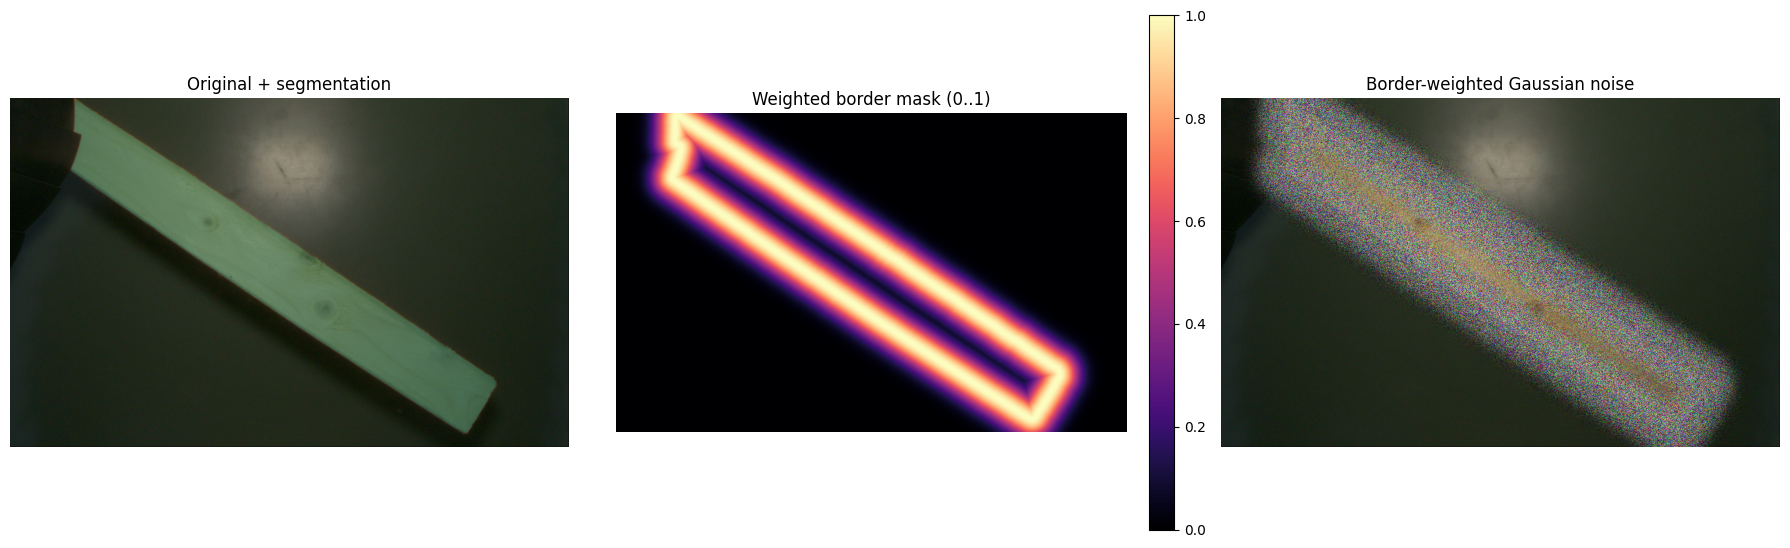

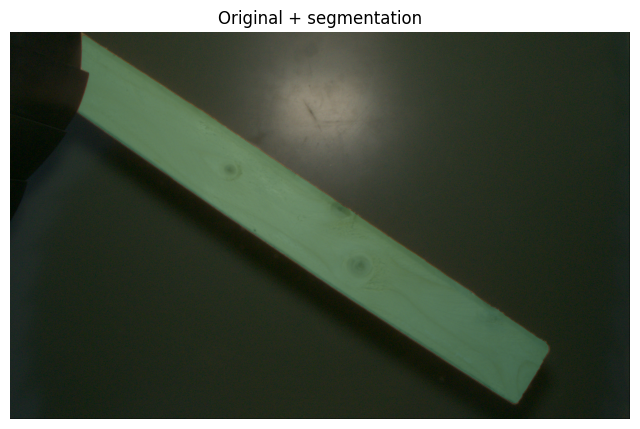

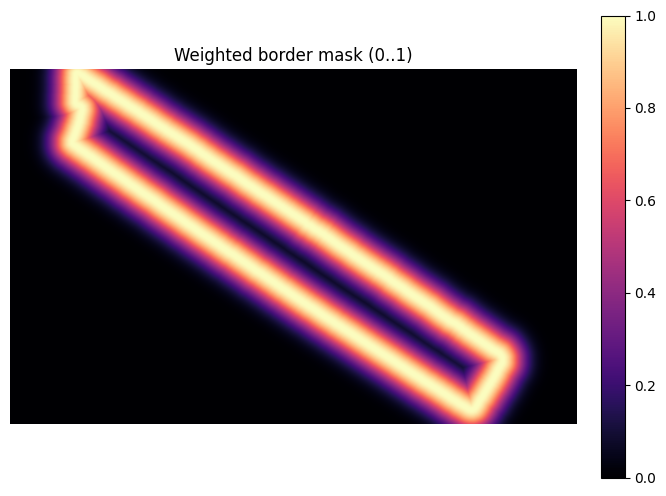

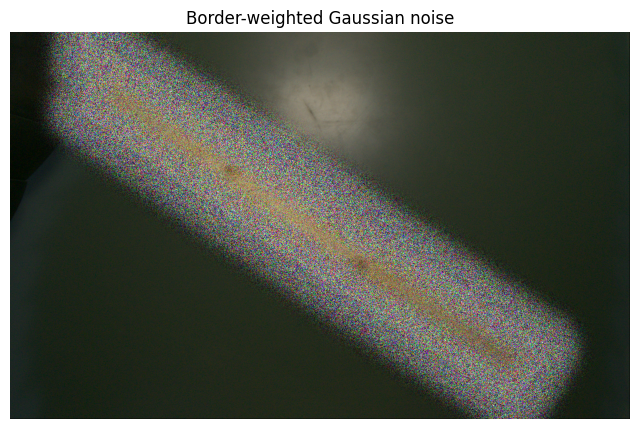

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy import ndimage

base_dir = Path("/home/ap/cloud/master/aris_master/figures/diffusion_paste/normal_wood")
annot_path = base_dir / "annots" / "annot_bold-eagle_2024-11-04T16-02-12-798.json"
image_path = base_dir / "images" / "img_bold-eagle_2024-11-04T16-02-12-798.png"

# --------------------
# Configuration knobs
# --------------------
seed = 7
noise_std_at_weight_1 = 600   # Pixel std (0-255 scale) when weight == 1.0
falloff_sigma_px = 50       # Larger -> slower decay away from border
max_distance_px = 300       # Border effect radius in pixels
max_weight = 1.0               # Clamp top weight (1.0 == 100% configured noise)

with annot_path.open("r", encoding="utf-8") as f:
    annot = json.load(f)

seg = annot["annotations"][0]["segmentation"]
height, width = annot["image_size"]

# Decode custom RLE representation into a 2D mask.
flat_mask = np.zeros(height * width, dtype=np.uint8)
for start, run in zip(seg["start_positions"], seg["run_lengths"]):
    flat_mask[start : start + run] = 1
mask = flat_mask.reshape((height, width)).astype(bool)

image = np.array(Image.open(image_path).convert("RGB"), dtype=np.float32)

# Create a thin border band around the mask, then compute per-pixel distance to it.
structure = np.ones((3, 3), dtype=bool)
inner = ndimage.binary_erosion(mask, structure=structure)
outer = ndimage.binary_dilation(mask, structure=structure)
border = outer ^ inner

dist_to_border = ndimage.distance_transform_edt(~border)

# Weight map: 1.0 at border, smoothly decaying with distance.
weight_map = np.exp(-(dist_to_border ** 2) / (2.0 * (falloff_sigma_px ** 2)))
weight_map[dist_to_border > max_distance_px] = 0.0
weight_map = np.clip(weight_map * max_weight, 0.0, 1.0).astype(np.float32)

# Apply Gaussian noise scaled by the weight map.
rng = np.random.default_rng(seed)
gaussian_noise = rng.normal(loc=0.0, scale=noise_std_at_weight_1, size=image.shape).astype(np.float32)
noisy_image = np.clip(image + gaussian_noise * weight_map[..., None], 0, 255).astype(np.uint8)

# Segmentation overlay for quick visual sanity check.
seg_overlay = np.ma.masked_where(~mask, mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image.astype(np.uint8))
axes[0].imshow(seg_overlay, cmap="summer", alpha=0.35)
axes[0].set_title("Original + segmentation")
axes[0].axis("off")

im = axes[1].imshow(weight_map, cmap="magma", vmin=0.0, vmax=1.0)
axes[1].set_title("Weighted border mask (0..1)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(noisy_image)
axes[2].set_title("Border-weighted Gaussian noise")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Standalone plot: original + segmentation overlay.
plt.figure(figsize=(8, 6))
plt.imshow(image.astype(np.uint8))
plt.imshow(seg_overlay, cmap="summer", alpha=0.35)
plt.title("Original + segmentation")
plt.axis("off")
plt.show()

# Standalone plot: weighted border mask.
plt.figure(figsize=(8, 6))
im = plt.imshow(weight_map, cmap="magma", vmin=0.0, vmax=1.0)
plt.title("Weighted border mask (0..1)")
plt.axis("off")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

# Standalone plot: border-weighted noisy image.
plt.figure(figsize=(8, 6))
plt.imshow(noisy_image)
plt.title("Border-weighted Gaussian noise")
plt.axis("off")
plt.show()